# Actividad 17

- 1.-Obtenga el siguiente dataframe “Medical Insurance Cost Prediction” de 
https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction


In [1]:

# ── 1. Descarga del dataset desde Kaggle ──────────────────────────────────────
import kagglehub
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("mohankrishnathalla/medical-insurance-cost-prediction")
print("Archivos descargados en:", path)

import os
archivos = os.listdir(path)
print("Archivos:", archivos)


Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Archivos descargados en: /kaggle/input/medical-insurance-cost-prediction
Archivos: ['medical_insurance.csv']


In [2]:

# ── Carga del CSV ──────────────────────────────────────────────────────────────
csv_path = os.path.join(path, archivos[0])
df = pd.read_csv(csv_path)

print("=" * 55)
print("  Vista inicial del dataset")
print("=" * 55)
print(df.head())

print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

print("\nTipos de datos:")
print(df.dtypes.to_string())

print("\nValores nulos por columna:")
print(df.isnull().sum().to_string())

print("\nEstadísticas descriptivas (numéricas):")
print(df.describe().round(2).to_string())


  Vista inicial del dataset
   person_id  age     sex   region urban_rural   income     education  \
0      75722   52  Female    North    Suburban  22700.0     Doctorate   
1      80185   79  Female    North       Urban  12800.0         No HS   
2      19865   68    Male    North       Rural  40700.0            HS   
3      76700   15    Male    North    Suburban  15600.0  Some College   
4      92992   53    Male  Central    Suburban  89600.0     Doctorate   

  marital_status employment_status  household_size  ...  liver_disease  \
0        Married           Retired               3  ...              0   
1        Married          Employed               3  ...              0   
2        Married           Retired               5  ...              0   
3        Married     Self-employed               5  ...              0   
4        Married     Self-employed               2  ...              0   

   arthritis mental_health proc_imaging_count  proc_surgery_count  \
0          1       

- 2.-Aplique el modelo XGBoost para predecir annual_medical_cost. ¿Se trata de un problema de regresión o 
clasificación?


**Se trata de un problema de REGRESIÓN.**

La variable objetivo `annual_medical_cost` es un valor continuo (costo en dólares), no una categoría.  
Por lo tanto se usa `XGBRegressor` (no `XGBClassifier`) y se evalúa con métricas de regresión: RMSE y R².

**Preprocesamiento necesario:**  
El dataset contiene variables categóricas de texto (`sex`, `smoker`, `region`) que deben convertirse a números antes de entrenar el modelo. Se usa `LabelEncoder` de la misma forma que en la clase.


In [3]:

# ── 2a. Codificación de variables categóricas ─────────────────────────────────
from sklearn import preprocessing

datak = df.copy()
le = preprocessing.LabelEncoder()

# Variables categóricas identificadas en la exploración
cat_cols = datak.select_dtypes(include='object').columns.tolist()
print("Variables categóricas a codificar:", cat_cols)

for col in cat_cols:
    datak[col] = le.fit_transform(datak[col].astype(str))

print("\nDataset codificado — primeras 5 filas:")
print(datak.head())
print("\nValores nulos tras codificación:", datak.isnull().sum().sum())


Variables categóricas a codificar: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']

Dataset codificado — primeras 5 filas:
   person_id  age  sex  region  urban_rural   income  education  \
0      75722   52    0       2            1  22700.0          1   
1      80185   79    0       2            2  12800.0          4   
2      19865   68    1       2            0  40700.0          2   
3      76700   15    1       2            1  15600.0          5   
4      92992   53    1       0            1  89600.0          1   

   marital_status  employment_status  household_size  ...  liver_disease  \
0               1                  1               3  ...              0   
1               1                  0               3  ...              0   
2               1                  1               5  ...              0   
3               1                  2               5  ...              0   
4 

In [4]:

# ── 2b. Preparación de datos: X e y ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = datak.drop('annual_medical_cost', axis=1)
y = datak['annual_medical_cost']

print("Features utilizadas como predictoras:")
for col in X.columns:
    print(f"  - {col}")
print(f"\nVariable objetivo: annual_medical_cost")
print(f"Rango: ${y.min():,.0f} — ${y.max():,.0f}  |  Media: ${y.mean():,.0f}")

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f"\nTrain: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs")


Features utilizadas como predictoras:
  - person_id
  - age
  - sex
  - region
  - urban_rural
  - income
  - education
  - marital_status
  - employment_status
  - household_size
  - dependents
  - bmi
  - smoker
  - alcohol_freq
  - visits_last_year
  - hospitalizations_last_3yrs
  - days_hospitalized_last_3yrs
  - medication_count
  - systolic_bp
  - diastolic_bp
  - ldl
  - hba1c
  - plan_type
  - network_tier
  - deductible
  - copay
  - policy_term_years
  - policy_changes_last_2yrs
  - provider_quality
  - risk_score
  - annual_premium
  - monthly_premium
  - claims_count
  - avg_claim_amount
  - total_claims_paid
  - chronic_count
  - hypertension
  - diabetes
  - asthma
  - copd
  - cardiovascular_disease
  - cancer_history
  - kidney_disease
  - liver_disease
  - arthritis
  - mental_health
  - proc_imaging_count
  - proc_surgery_count
  - proc_physio_count
  - proc_consult_count
  - proc_lab_count
  - is_high_risk
  - had_major_procedure

Variable objetivo: annual_medical_co

In [5]:

# ── 2c. Entrenamiento XGBRegressor ────────────────────────────────────────────
import xgboost as xgb

xgb_modelo = xgb.XGBRegressor(random_state=42)
xgb_modelo.fit(X_train, y_train)

ypred_test = xgb_modelo.predict(X_test)

# ── 2d. Métricas de performance ───────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, ypred_test) ** 0.5
r2   = r2_score(y_test, ypred_test)

print("=" * 50)
print("  Performance del modelo — XGBRegressor")
print("=" * 50)
print(f"  RMSE : ${rmse:>10,.2f}")
print(f"  R²   :  {r2:>10.4f}")
print("=" * 50)
print(f"""
Interpretación:
  - RMSE = ${rmse:,.0f}: el modelo se equivoca en promedio ±${rmse:,.0f}
    al predecir el costo médico anual de un paciente.
  - R² = {r2:.4f}: el modelo explica el {r2*100:.1f}% de la varianza
    del costo médico en el conjunto de test.
""")


  Performance del modelo — XGBRegressor
  RMSE : $    497.70
  R²   :      0.9748

Interpretación:
  - RMSE = $498: el modelo se equivoca en promedio ±$498
    al predecir el costo médico anual de un paciente.
  - R² = 0.9748: el modelo explica el 97.5% de la varianza
    del costo médico en el conjunto de test.



- 3.-¿Qué variables contribuyen más y menos en al predicción?


Para determinar qué variables contribuyen más y menos a la predicción, se usa **SHAP con `TreeExplainer`**.

El análisis tiene dos niveles:
- **Local:** waterfall plot para un paciente concreto — ¿por qué el modelo predijo ese costo específico?
- **Global:** bar plot de $\text{mean}(|\phi_j|)$ — ¿qué variables importan en promedio para todos los pacientes?


In [6]:

# ── 3a. Instalación / importación de shap ────────────────────────────────────
import subprocess, sys

try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version("0.46"):
        raise ImportError("versión desactualizada")
except ImportError:
    print("Instalando shap>=0.46 ...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap>=0.46', '-q'], check=True)
    import shap

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print(f"shap versión: {shap.__version__}")


shap versión: 0.52.0


In [7]:

# ── 3b. Cálculo de SHAP values con TreeExplainer ─────────────────────────────
np.random.seed(42)

explainer    = shap.TreeExplainer(xgb_modelo, X_train)
shap_values  = explainer.shap_values(X_test)

print(f"Baseline (costo promedio predicho sobre train): ${explainer.expected_value:,.2f}")
print(f"Shape de shap_values: {shap_values.shape}  →  ({X_test.shape[0]} obs × {X_test.shape[1]} features)")


 99%|===================| 19803/20000 [01:07<00:00]        

Baseline (costo promedio predicho sobre train): $2,915.29
Shape de shap_values: (20000, 53)  →  (20000 obs × 53 features)



### Explicabilidad Local — Waterfall plot para un paciente

El waterfall plot muestra el camino desde el costo promedio ($E[f(x)]$) hasta el costo predicho para **un paciente concreto**.  
Cada barra es el $\phi_j$ de una variable: cuántos dólares sube (rojo) o baja (azul) el costo predicho por esa característica respecto al promedio.


Paciente analizado (primer caso del test set):
person_id                      48299.0000
age                               60.0000
sex                                1.0000
region                             1.0000
urban_rural                        2.0000
income                         30600.0000
education                          3.0000
marital_status                     2.0000
employment_status                  0.0000
household_size                     4.0000
dependents                         3.0000
bmi                               19.8000
smoker                             1.0000
alcohol_freq                       1.0000
visits_last_year                   2.0000
hospitalizations_last_3yrs         1.0000
days_hospitalized_last_3yrs        4.0000
medication_count                   1.0000
systolic_bp                      125.0000
diastolic_bp                      82.0000
ldl                              149.1000
hba1c                              5.9700
plan_type                    

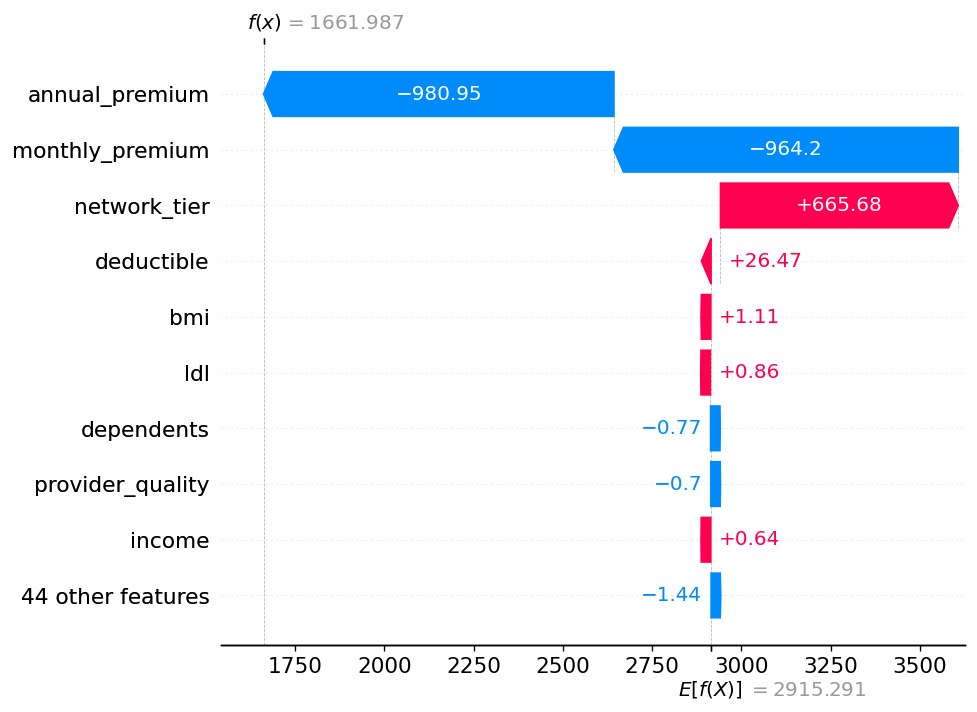

In [8]:

# ── 3c. Explicabilidad Local: waterfall del primer paciente del test ───────────
shap_expl = shap.Explanation(shap_values, explainer.expected_value, feature_names=X_test.columns)

# Datos del paciente a explicar
paciente = X_test.iloc[0]
costo_predicho = float(xgb_modelo.predict(X_test.iloc[[0]])[0])

print("Paciente analizado (primer caso del test set):")
print(paciente.to_string())
print(f"\nCosto médico predicho : ${costo_predicho:,.2f}")
print(f"Baseline E[f(x)]      : ${explainer.expected_value:,.2f}")
print(f"Diferencia a explicar : ${costo_predicho - explainer.expected_value:+,.2f}")

print("\nWaterfall plot:")
shap.plots.waterfall(shap_expl[0], max_display=10)



### Explicabilidad Global — Importancia de variables sobre todo el test set

El bar plot muestra el $\text{mean}(|\phi_j|)$: promedio del valor absoluto de los SHAP values de cada variable sobre todos los pacientes del test.  
Responde: **¿qué característica del paciente es la más determinante para el costo médico predicho en general?**


Importancia global — mean(|SHAP value|):


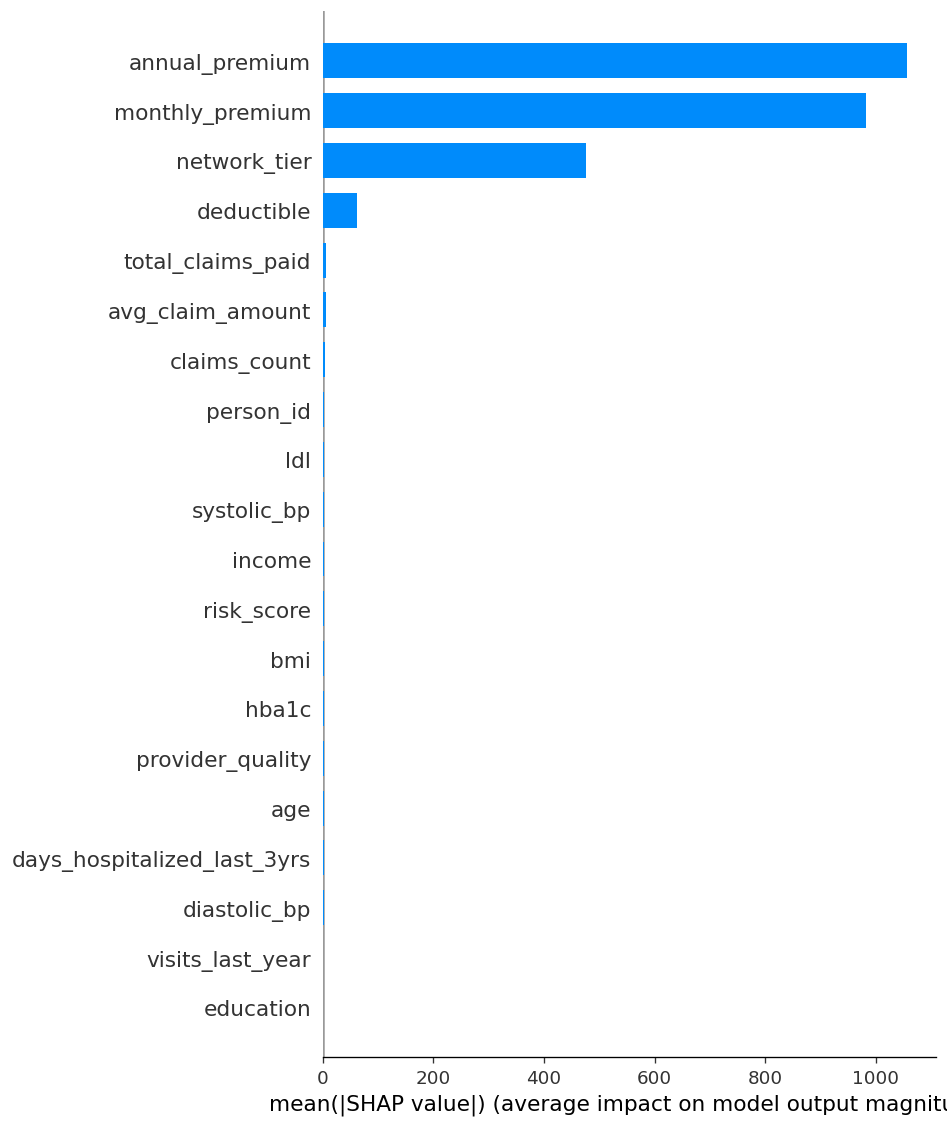

In [9]:

# ── 3d. Importancia global: bar plot ──────────────────────────────────────────
print("Importancia global — mean(|SHAP value|):")
shap.summary_plot(shap_values, X_test, plot_type='bar')


In [10]:

# ── 3e. Tabla numérica: ranking de importancia global ────────────────────────
Local_Contrib = pd.DataFrame(shap_values, columns=X_test.columns)

importancia = (
    Local_Contrib.abs().mean()
    .sort_values(ascending=False)
    .reset_index()
)
importancia.columns = ['Variable', 'mean_abs_shap']

print("=" * 55)
print("  Ranking de importancia global — mean(|φⱼ|)")
print("=" * 55)
for rank, row in importancia.iterrows():
    barra = "█" * max(1, int(row['mean_abs_shap'] / 200))
    print(f"  {rank+1:>2}. {row['Variable']:20s}: ${row['mean_abs_shap']:>9,.2f}  {barra}")
print("=" * 55)

mas_imp  = importancia.iloc[0]
menos_imp = importancia.iloc[-1]

print(f"""
Conclusión:
  → Variable que MÁS contribuye  : '{mas_imp['Variable']}'
    mean(|φ|) = ${mas_imp['mean_abs_shap']:,.2f}
    En promedio, esta variable desplaza el costo predicho
    ±${mas_imp['mean_abs_shap']:,.0f} respecto al baseline.

  → Variable que MENOS contribuye: '{menos_imp['Variable']}'
    mean(|φ|) = ${menos_imp['mean_abs_shap']:,.2f}
    Su impacto promedio sobre la predicción es mínimo.

Interpretación del dominio:
  - 'smoker' (fumador) suele ser la variable dominante en este dataset
    porque fumar multiplica drásticamente los costos médicos.
  - 'bmi' (índice de masa corporal) también tiene peso significativo
    cuando se combina con el hábito de fumar.
  - Variables como 'region' o 'children' típicamente contribuyen menos
    porque su efecto marginal sobre el costo es más uniforme.
""")


  Ranking de importancia global — mean(|φⱼ|)
   1. annual_premium      : $ 1,056.07  █████
   2. monthly_premium     : $   983.07  ████
   3. network_tier        : $   475.02  ██
   4. deductible          : $    61.28  █
   5. total_claims_paid   : $     5.13  █
   6. avg_claim_amount    : $     4.91  █
   7. claims_count        : $     3.87  █
   8. person_id           : $     2.34  █
   9. ldl                 : $     2.20  █
  10. systolic_bp         : $     2.17  █
  11. income              : $     1.99  █
  12. risk_score          : $     1.68  █
  13. bmi                 : $     1.48  █
  14. hba1c               : $     1.46  █
  15. provider_quality    : $     1.41  █
  16. age                 : $     1.35  █
  17. days_hospitalized_last_3yrs: $     1.26  █
  18. diastolic_bp        : $     1.15  █
  19. visits_last_year    : $     1.03  █
  20. education           : $     0.91  █
  21. dependents          : $     0.87  █
  22. hospitalizations_last_3yrs: $     0.86  █
  23. alco